In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
sns.set_theme(style="whitegrid")

df1 = pd.read_csv('sesi-1.csv')
df2 = pd.read_csv('sesi-2.csv')


In [5]:
def konversi_waktu_ke_menit(waktu_str):
    if pd.isna(waktu_str):
        return 0
    jam, menit, detik = map(int, str(waktu_str).split(':'))
    return (jam * 60) + menit + (detik / 60.0)

df1['total_waktu_menit'] = df1['total_waktu'].apply(konversi_waktu_ke_menit)
df2['total_waktu_menit'] = df2['total_waktu'].apply(konversi_waktu_ke_menit)

In [6]:
df_merged = pd.merge(
    df1, df2, 
    on=['nomer_induk', 'nama'], 
    suffixes=('_sesi1', '_sesi2'), 
    how='inner'
)

In [7]:
print(f"Total siswa yang mengikuti kedua sesi: {len(df_merged)} siswa\n")

Total siswa yang mengikuti kedua sesi: 56 siswa



In [8]:
mean_skor_1, mean_skor_2 = df_merged['skor_akhir_sesi1'].mean(), df_merged['skor_akhir_sesi2'].mean()
mean_waktu_1, mean_waktu_2 = df_merged['total_waktu_menit_sesi1'].mean(), df_merged['total_waktu_menit_sesi2'].mean()
mean_akurasi_1, mean_akurasi_2 = df_merged['akurasi_menjawab_sesi1'].mean(), df_merged['akurasi_menjawab_sesi2'].mean()

In [9]:
print(f"Rata-rata Skor Akhir    : Sesi 1 ({mean_skor_1:.2f}) vs Sesi 2 ({mean_skor_2:.2f})")
print(f"Rata-rata Akurasi (%)   : Sesi 1 ({mean_akurasi_1:.2f}%) vs Sesi 2 ({mean_akurasi_2:.2f}%)")
print(f"Rata-rata Waktu (Menit) : Sesi 1 ({mean_waktu_1:.2f}) vs Sesi 2 ({mean_waktu_2:.2f})\n")

Rata-rata Skor Akhir    : Sesi 1 (34.26) vs Sesi 2 (37.25)
Rata-rata Akurasi (%)   : Sesi 1 (34.80%) vs Sesi 2 (38.92%)
Rata-rata Waktu (Menit) : Sesi 1 (43.48) vs Sesi 2 (30.09)



In [10]:
contoh_data = df_merged[['nama', 'skor_akhir_sesi1', 'skor_akhir_sesi2', 
                        'akurasi_menjawab_sesi1', 'akurasi_menjawab_sesi2']].head()
print(contoh_data.to_string(index=False))

                   nama  skor_akhir_sesi1  skor_akhir_sesi2  akurasi_menjawab_sesi1  akurasi_menjawab_sesi2
      Lathifatul Ihyati         80.232558         79.629630                    82.5                   73.33
     As Sohih Imaduddin         73.913043         51.533742                    75.0                   55.88
           Fina Maisara         58.865248         35.483871                    52.5                   35.29
    Rivan Akbar Pratama         57.258065         60.824742                    45.0                   61.90
Callysta Aryago Aryaago         55.208333         29.032258                    65.0                   33.33


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16188\1842946352.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sesi 1', 'Sesi 2'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16188\1842946352.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Sesi 1', 'Sesi 2'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16188\1842946352.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Sesi 1', 'Sesi 2'])


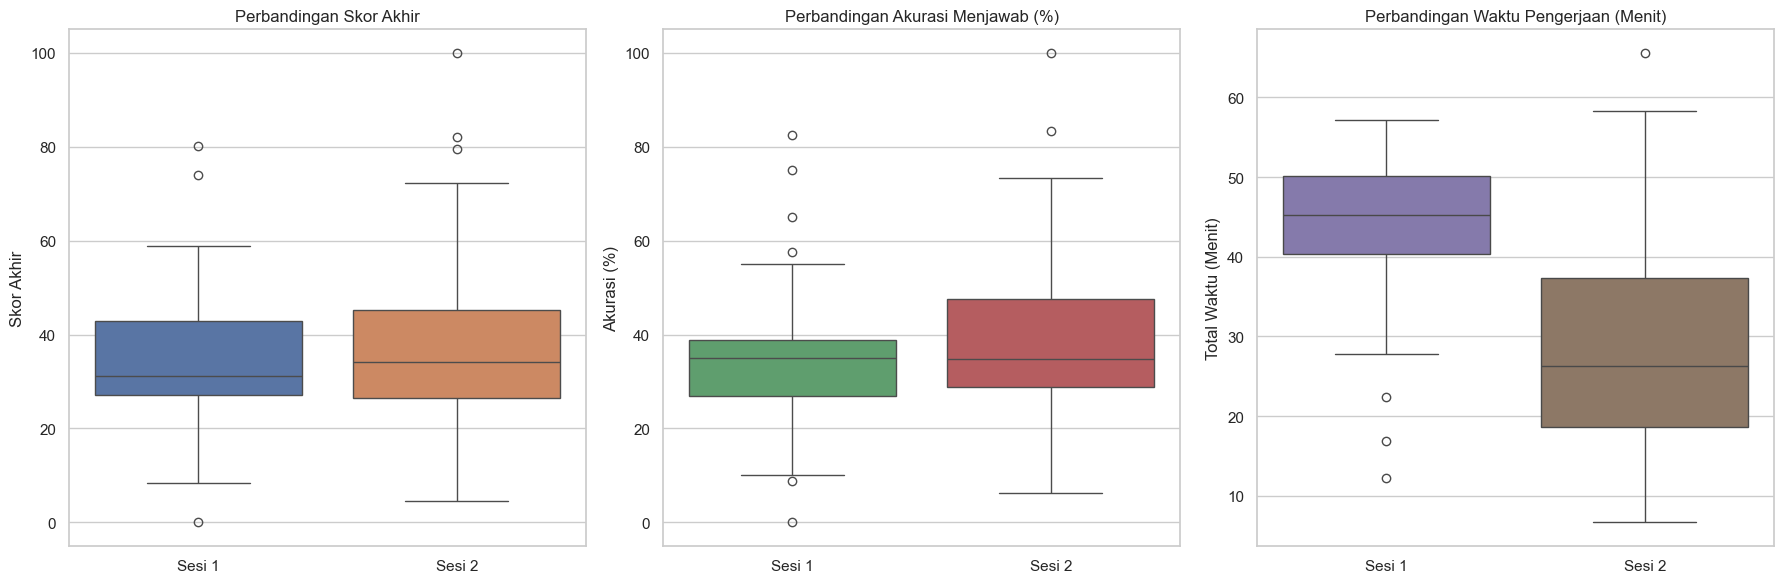

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df_merged[['skor_akhir_sesi1', 'skor_akhir_sesi2']], ax=axes[0], palette=['#4c72b0', '#dd8452'])
axes[0].set_title('Perbandingan Skor Akhir')
axes[0].set_xticklabels(['Sesi 1', 'Sesi 2'])
axes[0].set_ylabel('Skor Akhir')

sns.boxplot(data=df_merged[['akurasi_menjawab_sesi1', 'akurasi_menjawab_sesi2']], ax=axes[1], palette=['#55a868', '#c44e52'])
axes[1].set_title('Perbandingan Akurasi Menjawab (%)')
axes[1].set_xticklabels(['Sesi 1', 'Sesi 2'])
axes[1].set_ylabel('Akurasi (%)')

sns.boxplot(data=df_merged[['total_waktu_menit_sesi1', 'total_waktu_menit_sesi2']], ax=axes[2], palette=['#8172b3', '#937860'])
axes[2].set_title('Perbandingan Waktu Pengerjaan (Menit)')
axes[2].set_xticklabels(['Sesi 1', 'Sesi 2'])
axes[2].set_ylabel('Total Waktu (Menit)')

plt.tight_layout()
plt.show()

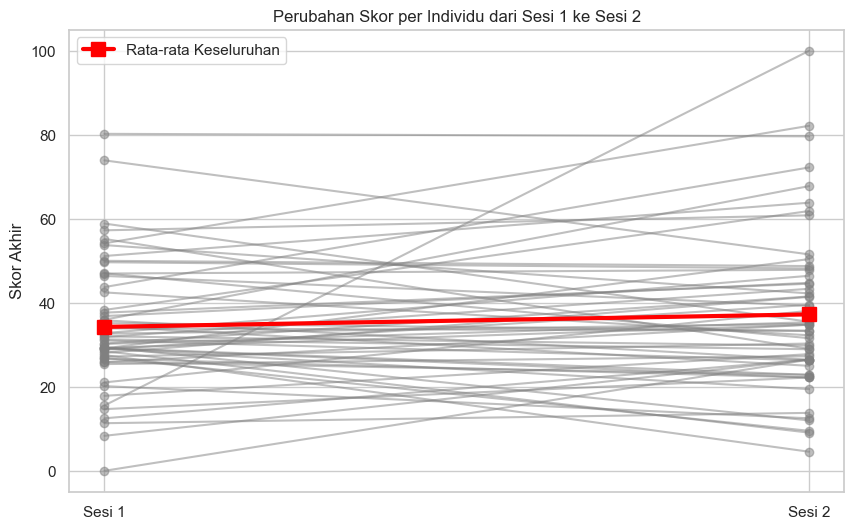

In [13]:
plt.figure(figsize=(10, 6))
for i in range(len(df_merged)):
    plt.plot([1, 2], [df_merged['skor_akhir_sesi1'].iloc[i], df_merged['skor_akhir_sesi2'].iloc[i]], 
             marker='o', color='gray', alpha=0.5)

# Garis rata-rata
plt.plot([1, 2], [mean_skor_1, mean_skor_2], marker='s', color='red', linewidth=3, markersize=10, label='Rata-rata Keseluruhan')

plt.xticks([1, 2], ['Sesi 1', 'Sesi 2'])
plt.ylabel('Skor Akhir')
plt.title('Perubahan Skor per Individu dari Sesi 1 ke Sesi 2')
plt.legend()
plt.show()